In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path
import sys

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root  :", PROJECT_ROOT)
print("Data folder   :", DATA_DIR)
print("Models folder :", MODELS_DIR)
print("Reports folder:", REPORTS_DIR)

Project root  : c:\Users\Imesh\Documents\NLP_Group_39
Data folder   : c:\Users\Imesh\Documents\NLP_Group_39\data
Models folder : c:\Users\Imesh\Documents\NLP_Group_39\models
Reports folder: c:\Users\Imesh\Documents\NLP_Group_39\reports


In [3]:
from data_loader import load_news_data
from preprocessing import clean_text

print("Data loading and preprocessing functions imported successfully.")

Data loading and preprocessing functions imported successfully.


In [4]:
dataset = load_news_data()

print("Dataset loaded successfully.")
print("Dataset shape:", dataset.shape)

dataset.head()

Dataset loaded successfully.
Dataset shape: (44898, 6)


,title,text,subject,date,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...


In [5]:
print("Dataset columns:")
print(dataset.columns.tolist())

print("\nDataset information:")
dataset.info()

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nClass distribution:")
print(dataset["label"].value_counts().sort_index())

print("\nLabel mapping:")
print("0 = Fake News")
print("1 = Real News")

Dataset columns:
['title', 'text', 'subject', 'date', 'label', 'content']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
 5   content  44898 non-null  str  
dtypes: int64(1), str(5)
memory usage: 2.1 MB

Missing values:
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64

Class distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Label mapping:
0 = Fake News
1 = Real News


## Data Preprocessing

The news text is normalized by converting it to lowercase and removing URLs, email addresses, HTML tags, numbers, punctuation marks, special characters, and unnecessary spaces.

In [6]:
svm_dataset = dataset.copy()

print("Starting SVM text preprocessing...")

svm_dataset["clean_content"] = (
    svm_dataset["content"]
    .astype(str)
    .apply(clean_text)
)

# Remove empty articles after preprocessing
svm_dataset = svm_dataset[
    svm_dataset["clean_content"].str.strip() != ""
].copy()

svm_dataset = svm_dataset.reset_index(drop=True)

print("Text preprocessing completed.")

print("Original dataset shape:", dataset.shape)
print("Cleaned dataset shape :", svm_dataset.shape)

print("\nMissing values after preprocessing:")
print(
    svm_dataset[
        ["content", "clean_content", "label"]
    ].isnull().sum()
)

Starting SVM text preprocessing...
Text preprocessing completed.
Original dataset shape: (44898, 6)
Cleaned dataset shape : (44889, 7)

Missing values after preprocessing:
content          0
clean_content    0
label            0
dtype: int64


In [7]:
sample_original = svm_dataset.loc[0, "content"]
sample_cleaned = svm_dataset.loc[0, "clean_content"]

print("Original text:")
print(sample_original[:500])

print("\nCleaned text:")
print(sample_cleaned[:500])

Original text:
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, 

Cleaned text:
donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want to wish all of my friends supporters enemies haters and even the very dishonest 

## Exploratory Data Analysis

This section examines the class distribution, article length patterns, and frequently occurring words in fake and real news articles.

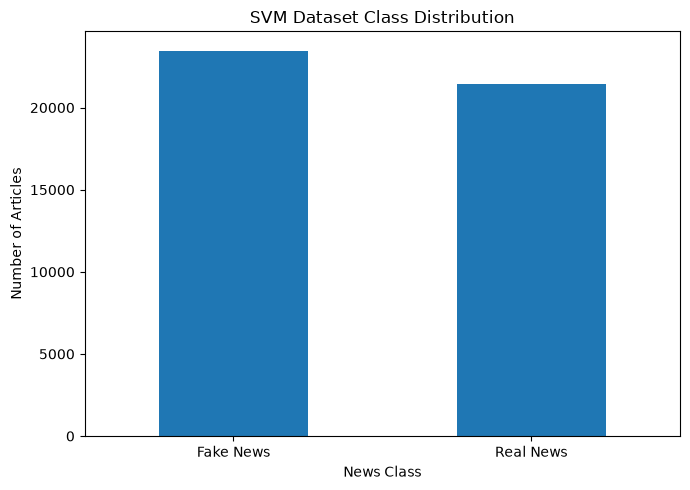

Class distribution:
label
0    23472
1    21417
Name: count, dtype: int64

Chart saved to:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_class_distribution.png


In [8]:
svm_class_distribution = (
    svm_dataset["label"]
    .value_counts()
    .sort_index()
)

class_names = svm_class_distribution.rename(
    index={
        0: "Fake News",
        1: "Real News"
    }
)

class_names.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("SVM Dataset Class Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()

svm_class_chart_path = (
    REPORTS_DIR
    / "svm_class_distribution.png"
)

plt.savefig(
    svm_class_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Class distribution:")
print(svm_class_distribution)

print("\nChart saved to:")
print(svm_class_chart_path)

In [9]:
svm_dataset["word_count"] = (
    svm_dataset["clean_content"]
    .str.split()
    .str.len()
)

article_length_summary = (
    svm_dataset
    .groupby("label")["word_count"]
    .describe()
)

print("Article length summary:")
display(article_length_summary)

Article length summary:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,23472.0,444.412364,413.957728,3.0,258.0,384.0,528.0,8295.0
1,21417.0,398.593641,276.821708,4.0,159.0,371.0,537.0,5254.0


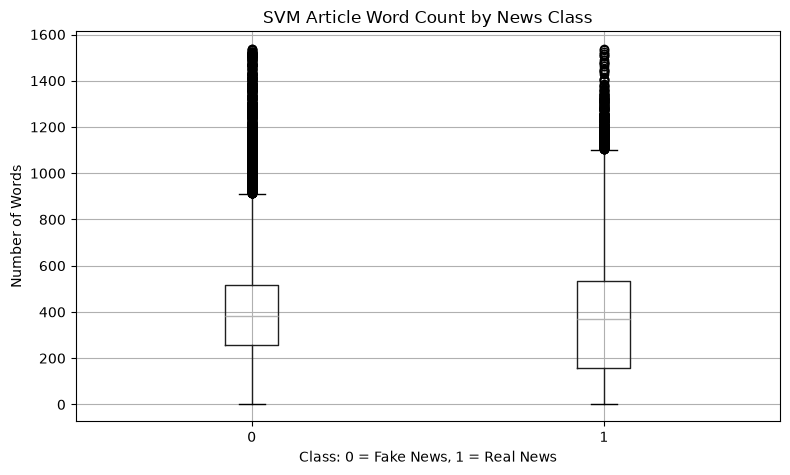

Chart saved to:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_article_length_distribution.png


In [10]:
maximum_display_length = (
    svm_dataset["word_count"].quantile(0.99)
)

length_plot_data = svm_dataset[
    svm_dataset["word_count"] <= maximum_display_length
].copy()

length_plot_data.boxplot(
    column="word_count",
    by="label",
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("SVM Article Word Count by News Class")
plt.xlabel("Class: 0 = Fake News, 1 = Real News")
plt.ylabel("Number of Words")
plt.tight_layout()

svm_length_chart_path = (
    REPORTS_DIR
    / "svm_article_length_distribution.png"
)

plt.savefig(
    svm_length_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:")
print(svm_length_chart_path)

In [11]:
def get_top_words(text_data, number_of_words=15):
    """
    Find the most frequent words in a collection
    of news articles.
    """

    sample_size = min(
        5000,
        len(text_data)
    )

    sampled_text = text_data.sample(
        n=sample_size,
        random_state=42
    )

    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000
    )

    word_matrix = vectorizer.fit_transform(
        sampled_text.astype(str)
    )

    frequencies = word_matrix.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    frequency_table = pd.DataFrame(
        {
            "Word": words,
            "Frequency": frequencies
        }
    )

    return (
        frequency_table
        .sort_values(
            "Frequency",
            ascending=False
        )
        .head(number_of_words)
        .reset_index(drop=True)
    )


print("Top-word function created successfully.")

Top-word function created successfully.


In [12]:
fake_top_words = get_top_words(
    svm_dataset.loc[
        svm_dataset["label"] == 0,
        "clean_content"
    ]
)

print("Most Frequent Words in Fake News:")
display(fake_top_words)

Most Frequent Words in Fake News:


,Word,Frequency
0,trump,18869
1,said,7487
2,president,6442
3,people,5794
4,just,4948
5,obama,4737
6,clinton,4450
7,donald,4102
8,like,3956
9,video,3556


In [13]:
real_top_words = get_top_words(
    svm_dataset.loc[
        svm_dataset["label"] == 1,
        "clean_content"
    ]
)

print("Most Frequent Words in Real News:")
display(real_top_words)

Most Frequent Words in Real News:


,Word,Frequency
0,said,23418
1,trump,14151
2,president,6794
3,reuters,6755
4,state,5171
5,government,4450
6,house,4176
7,new,4166
8,republican,3897
9,states,3815


In [14]:
X = svm_dataset["clean_content"].astype(str)
y = svm_dataset["label"].astype(int)

print("Number of news articles:", len(X))
print("Number of labels       :", len(y))

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Number of news articles: 44889
Number of labels       : 44889

Target distribution:
label
0    23472
1    21417
Name: count, dtype: int64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")

print("\nTraining records:", len(X_train))
print("Testing records :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Train-test split completed successfully.

Training records: 35911
Testing records : 8978

Training class distribution:
label
0    18777
1    17134
Name: count, dtype: int64

Testing class distribution:
label
0    4695
1    4283
Name: count, dtype: int64


## Feature Engineering Using TF-IDF

TF-IDF converts cleaned news articles into numerical feature vectors. Unigrams and bigrams are used to represent individual words and short word sequences for the SVM classifier.

In [16]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created successfully.")

TF-IDF vectorizer created successfully.


In [17]:
print("TF-IDF feature extraction started...")

X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test
)

print("TF-IDF feature extraction completed.")

print("\nTraining feature shape:", X_train_tfidf.shape)
print("Testing feature shape :", X_test_tfidf.shape)

print(
    "Vocabulary size:",
    len(tfidf_vectorizer.vocabulary_)
)

TF-IDF feature extraction started...
TF-IDF feature extraction completed.

Training feature shape: (35911, 50000)
Testing feature shape : (8978, 50000)
Vocabulary size: 50000


In [18]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("First 20 TF-IDF features:")
print(feature_names[:20])

print("\nLast 20 TF-IDF features:")
print(feature_names[-20:])

First 20 TF-IDF features:
['aa' 'aadhaar' 'aapl' 'aaron' 'ab' 'aba' 'ababa' 'aback' 'abadi'
 'abadi said' 'abandon' 'abandon nuclear' 'abandoned' 'abandoning' 'abas'
 'abas aslani' 'abbas' 'abbasi' 'abbott' 'abbott said']

Last 20 TF-IDF features:
['zip' 'zippers' 'zone' 'zone budget' 'zone listen' 'zone syria' 'zones'
 'zones syria' 'zoning' 'zoo' 'zor' 'zor city' 'zor province' 'zucker'
 'zuckerberg' 'zuckerberg said' 'zuma' 'zuma said' 'zurich'
 'zurich reuters']


## Support Vector Machine Model Development

Linear Support Vector Machine is selected because it performs effectively with high-dimensional sparse TF-IDF text features. Probability calibration is added to generate confidence scores and ROC-AUC values.

In [19]:
base_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

print("Base Linear SVM model created successfully.")

Base Linear SVM model created successfully.


In [20]:
svm_model = CalibratedClassifierCV(
    estimator=base_svm_model,
    method="sigmoid",
    cv=3,
    n_jobs=-1
)

print("Calibrated SVM model created successfully.")

Calibrated SVM model created successfully.


In [21]:
svm_model = CalibratedClassifierCV(
    base_svm_model,
    method="sigmoid",
    cv=3
)

In [22]:
print("SVM model training started...")

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("SVM model training completed successfully.")

SVM model training started...
SVM model training completed successfully.


In [23]:
y_pred = svm_model.predict(
    X_test_tfidf
)

y_probability = svm_model.predict_proba(
    X_test_tfidf
)[:, 1]

print("SVM predictions generated successfully.")

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].to_numpy())

print("\nFirst 10 Real News probabilities:")
print(y_probability[:10])

SVM predictions generated successfully.

First 10 predicted labels:
[1 1 0 0 1 0 0 0 1 0]

First 10 actual labels:
[1 1 0 0 1 0 0 0 1 0]

First 10 Real News probabilities:
[9.99354904e-01 9.99990366e-01 4.91327335e-06 4.03896465e-05
 9.99995531e-01 1.06582695e-03 5.00633702e-07 1.18014255e-03
 9.99998677e-01 3.56365175e-05]


In [24]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred
)

svm_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

svm_roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("SVM Evaluation Results")
print("=" * 45)

print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1-Score  : {svm_f1:.4f}")
print(f"ROC-AUC   : {svm_roc_auc:.4f}")

SVM Evaluation Results
Accuracy  : 0.9970
Precision : 0.9965
Recall    : 0.9972
F1-Score  : 0.9968
ROC-AUC   : 0.9999


In [25]:
svm_classification_report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Fake News",
        "Real News"
    ],
    zero_division=0
)

print("SVM Classification Report")
print("=" * 55)
print(svm_classification_report)

SVM Classification Report
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      4695
   Real News       1.00      1.00      1.00      4283

    accuracy                           1.00      8978
   macro avg       1.00      1.00      1.00      8978
weighted avg       1.00      1.00      1.00      8978



In [26]:
print("Exact SVM Evaluation Results")
print("=" * 45)

print(f"Accuracy  : {svm_accuracy:.6f}")
print(f"Precision : {svm_precision:.6f}")
print(f"Recall    : {svm_recall:.6f}")
print(f"F1-Score  : {svm_f1:.6f}")
print(f"ROC-AUC   : {svm_roc_auc:.6f}")

Exact SVM Evaluation Results
Accuracy  : 0.996993
Precision : 0.996500
Recall    : 0.997198
F1-Score  : 0.996849
ROC-AUC   : 0.999867


In [27]:
train_text_set = set(X_train.astype(str))
test_text_set = set(X_test.astype(str))

overlapping_articles = train_text_set.intersection(
    test_text_set
)

print("Exact duplicate articles shared between train and test:")
print(len(overlapping_articles))

Exact duplicate articles shared between train and test:
1883


## SVM Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified fake and real news articles.

In [28]:
svm_confusion_values = confusion_matrix(
    y_test,
    y_pred
)

print("SVM Confusion Matrix:")
print(svm_confusion_values)

true_fake = svm_confusion_values[0, 0]
false_real = svm_confusion_values[0, 1]
false_fake = svm_confusion_values[1, 0]
true_real = svm_confusion_values[1, 1]

print("\nConfusion Matrix Explanation")
print("=" * 45)

print(
    "Fake news correctly predicted as Fake :",
    true_fake
)

print(
    "Fake news incorrectly predicted as Real:",
    false_real
)

print(
    "Real news incorrectly predicted as Fake:",
    false_fake
)

print(
    "Real news correctly predicted as Real  :",
    true_real
)

SVM Confusion Matrix:
[[4680   15]
 [  12 4271]]

Confusion Matrix Explanation
Fake news correctly predicted as Fake : 4680
Fake news incorrectly predicted as Real: 15
Real news incorrectly predicted as Fake: 12
Real news correctly predicted as Real  : 4271


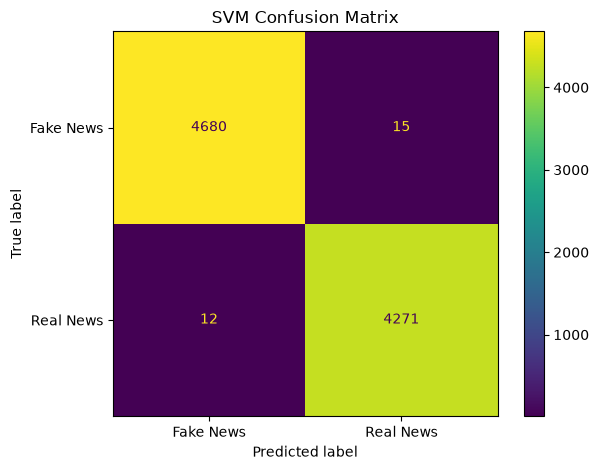

Confusion matrix saved to:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_confusion_matrix.png


In [29]:
svm_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=svm_confusion_values,
    display_labels=[
        "Fake News",
        "Real News"
    ]
)

svm_matrix_display.plot(
    values_format="d"
)

plt.title("SVM Confusion Matrix")
plt.tight_layout()

svm_confusion_matrix_path = (
    REPORTS_DIR
    / "svm_confusion_matrix.png"
)

plt.savefig(
    svm_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(svm_confusion_matrix_path)

## SVM ROC Curve

The ROC curve evaluates the SVM model across different classification thresholds. A ROC-AUC score closer to 1 indicates stronger classification performance.

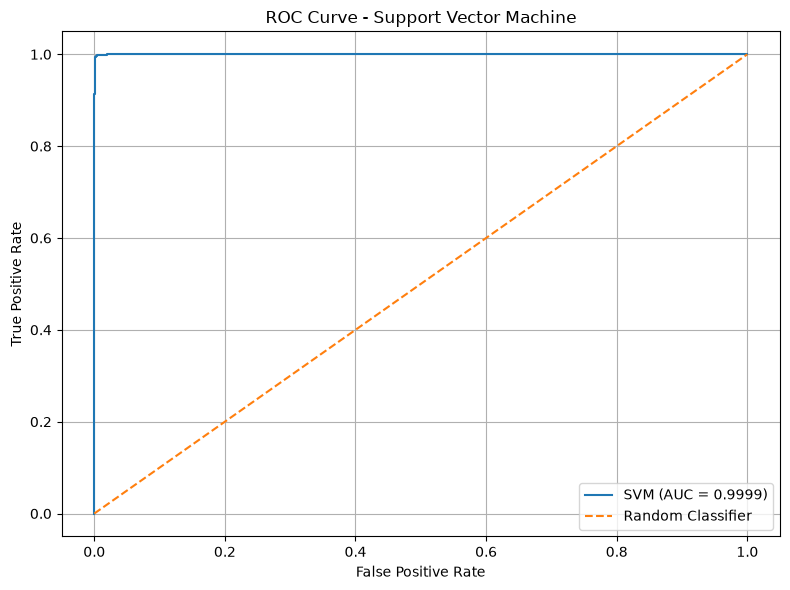

ROC curve saved to:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_roc_curve.png


In [30]:
svm_false_positive_rate, svm_true_positive_rate, thresholds = (
    roc_curve(
        y_test,
        y_probability
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    svm_false_positive_rate,
    svm_true_positive_rate,
    label=f"SVM (AUC = {svm_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Support Vector Machine")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()

svm_roc_curve_path = (
    REPORTS_DIR
    / "svm_roc_curve.png"
)

plt.savefig(
    svm_roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved to:")
print(svm_roc_curve_path)

In [31]:
svm_metrics_dataframe = pd.DataFrame(
    {
        "Model": ["Support Vector Machine"],
        "Accuracy": [svm_accuracy],
        "Precision": [svm_precision],
        "Recall": [svm_recall],
        "F1-Score": [svm_f1],
        "ROC-AUC": [svm_roc_auc]
    }
)

svm_metrics_path = (
    REPORTS_DIR
    / "svm_metrics.csv"
)

svm_metrics_dataframe.to_csv(
    svm_metrics_path,
    index=False
)

print("SVM metrics saved successfully.")

display(svm_metrics_dataframe)

print("\nMetrics file:")
print(svm_metrics_path)

SVM metrics saved successfully.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,0.996993,0.9965,0.997198,0.996849,0.999867



Metrics file:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_metrics.csv


In [32]:
svm_prediction_results = pd.DataFrame(
    {
        "News_Text": X_test.to_numpy(),
        "Actual_Label": y_test.to_numpy(),
        "Predicted_Label": y_pred,
        "Real_News_Probability": y_probability,
        "Fake_News_Probability": (
            1 - y_probability
        )
    }
)

svm_predictions_path = (
    REPORTS_DIR
    / "svm_test_predictions.csv"
)

svm_prediction_results.to_csv(
    svm_predictions_path,
    index=False
)

print("SVM test predictions saved successfully.")
print(
    "Number of saved predictions:",
    len(svm_prediction_results)
)

display(svm_prediction_results.head())

print("\nPredictions file:")
print(svm_predictions_path)

SVM test predictions saved successfully.
Number of saved predictions: 8978


,News_Text,Actual_Label,Predicted_Label,Real_News_Probability,Fake_News_Probability
0,germany s merkel suffers state vote setback as...,1,1,0.999355,0.000645
1,britain germany committed to iran nuclear deal...,1,1,0.999990,0.000010
2,watch defiant muslim refugees tell british cit...,0,0,0.000005,0.999995
3,breaking it looks like russia hacked our votin...,0,0,0.000040,0.999960
4,men found at northern japan marina say they ar...,1,1,0.999996,0.000004



Predictions file:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_test_predictions.csv


In [33]:
svm_model_path = (
    MODELS_DIR
    / "svm_model.joblib"
)

svm_vectorizer_path = (
    MODELS_DIR
    / "svm_tfidf_vectorizer.joblib"
)

joblib.dump(
    svm_model,
    svm_model_path
)

joblib.dump(
    tfidf_vectorizer,
    svm_vectorizer_path
)

print("SVM model and TF-IDF vectorizer saved successfully.")

print("\nModel path:")
print(svm_model_path)

print("\nVectorizer path:")
print(svm_vectorizer_path)

SVM model and TF-IDF vectorizer saved successfully.

Model path:
c:\Users\Imesh\Documents\NLP_Group_39\models\svm_model.joblib

Vectorizer path:
c:\Users\Imesh\Documents\NLP_Group_39\models\svm_tfidf_vectorizer.joblib


In [34]:
import re

def is_valid_news_text(text):
    """
    Reject empty, too-short, or gibberish/random text before model prediction.
    Returns: (is_valid, cleaned_text_or_error_message)
    """
    if text is None:
        return False, "Input is empty."

    text = str(text).strip()
    if not text:
        return False, "Please enter a news article."

    # Minimum length check
    if len(text) < 20:
        return False, "Article is too short to be a valid news article."

    words = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", text)
    if len(words) < 3:
        return False, "Input must contain at least 3 meaningful words."

    clean_words = [w.lower() for w in words if len(w) > 2]
    if not clean_words:
        return False, "Input does not contain readable text."

    gibberish_count = 0
    for word in clean_words:
        if len(word) < 4:
            continue

        vowel_ratio = sum(ch in "aeiou" for ch in word) / len(word)
        has_repeated_chars = bool(re.search(r"(.)\1{2,}", word))
        has_long_consonant_block = bool(re.search(r"[bcdfghjklmnpqrstvwxyz]{5,}", word))

        if vowel_ratio < 0.18 or has_repeated_chars or has_long_consonant_block:
            gibberish_count += 1

    if len(clean_words) > 0 and (gibberish_count / len(clean_words)) > 0.35:
        return False, "Input appears to be random or gibberish text, not a valid news article."

    return True, " ".join(clean_words)

In [35]:
import ipywidgets as widgets
from IPython.display import display

text_input = widgets.Textarea(
    value="",
    placeholder="Paste a news article here...",
    description="News:",
    rows=8,
    layout=widgets.Layout(width="100%", min_height="150px")
)

result = widgets.HTML(
    value="<b>Prediction:</b> Waiting for input..."
)

predict_button = widgets.Button(
    description="Check Fake/Real",
    button_style="primary",
    layout=widgets.Layout(width="180px")
)

def run_prediction(_):
    article = text_input.value.strip()

    if not article:
        result.value = "<b>Invalid input:</b> Please enter a news article."
        return

    is_valid, validation_message = is_valid_news_text(article)
    if not is_valid:
        result.value = f"<b>Invalid input:</b> {validation_message}"
        return

    cleaned_text = validation_message
    features = tfidf_vectorizer.transform([cleaned_text])

    predicted_label = int(svm_model.predict(features)[0])
    probabilities = svm_model.predict_proba(features)[0]
    class_positions = {int(label): idx for idx, label in enumerate(svm_model.classes_)}

    fake_probability = float(probabilities[class_positions[0]])
    real_probability = float(probabilities[class_positions[1]])
    confidence = max(fake_probability, real_probability)

    prediction_name = "REAL NEWS" if predicted_label == 1 else "FAKE NEWS"

    result.value = (
        f"<b>Prediction:</b> {prediction_name}<br>"
        f"<b>Confidence:</b> {confidence * 100:.2f}%<br>"
        f"<b>Fake probability:</b> {fake_probability * 100:.2f}%<br>"
        f"<b>Real probability:</b> {real_probability * 100:.2f}%"
    )

predict_button.on_click(run_prediction)

display(widgets.VBox([
    text_input,
    predict_button,
    result
]))